<a href="https://colab.research.google.com/github/DarkLyng/Challenge-TelecomX/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [3]:
#Bibliotecas

import requests
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
#Enlace

enlace = "https://github.com/ingridcristh/challenge2-data-science-LATAM/blob/main/TelecomX_Data.json" #No funciona
enlace_raw = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

In [5]:
#Cargando los datos de Telecom X
r = requests.get(enlace_raw)
data = r.json()
df = pd.DataFrame(data)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [6]:
#Obteniendo información de los datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [7]:
#Normalizando el archivo TelecomX_Data.json
df_normalizado = pd.json_normalize(data)
df_normalizado.sample(10)

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
3312,4616-ULAOA,No,Female,0,Yes,Yes,65,Yes,Yes,Fiber optic,...,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),110.80,7245.9
4316,5928-QLDHB,No,Male,0,No,No,9,Yes,Yes,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,76.25,684.85
1083,1535-VTJOQ,No,Female,0,No,No,24,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),25.15,553
1401,2025-JKFWI,Yes,Male,0,No,No,13,Yes,Yes,Fiber optic,...,No,No,Yes,Yes,Yes,Month-to-month,Yes,Mailed check,99.00,1301.7
723,1036-GUDCL,No,Male,0,Yes,Yes,60,Yes,No,DSL,...,Yes,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),79.05,4663.4
144,0233-FTHAV,No,Female,0,No,No,60,Yes,Yes,Fiber optic,...,No,Yes,No,No,No,One year,Yes,Bank transfer (automatic),79.20,4765
4067,5568-DMXZS,No,Female,0,No,No,8,Yes,No,DSL,...,Yes,No,Yes,Yes,No,Month-to-month,Yes,Electronic check,65.45,554.45
4842,6625-UTXEW,No,Female,0,Yes,No,12,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,51.25,612.1
1797,2560-PPCHE,No,Female,0,No,No,65,Yes,Yes,Fiber optic,...,Yes,No,Yes,Yes,Yes,One year,Yes,Bank transfer (automatic),105.05,6744.25
6501,8937-FVBIE,,Male,0,Yes,No,67,Yes,No,Fiber optic,...,Yes,No,No,No,Yes,One year,Yes,Credit card (automatic),90.60,6056.15


In [8]:
#Información de los datos normalizados
df_normalizado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [9]:
#Comprobación datos nulos
df_normalizado.isnull().sum().rename("Datos Nulos")

,Datos Nulos
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [10]:
#Comprobación de datos duplicados
df_normalizado.duplicated().sum()

np.int64(0)

In [11]:
#Comprobación de strings vacíos o con espacios en el DataFrame
for col in df_normalizado.select_dtypes(include='object').columns:
    espacios = df_normalizado[col].str.isspace().sum()
    vacios = (df_normalizado[col] == "").sum()
    if espacios > 0 or vacios > 0:
        print(f"Columna '{col}': {espacios} celdas con espacios y {vacios} celdas vacías.")

Columna 'Churn': 0 celdas con espacios y 224 celdas vacías.
Columna 'account.Charges.Total': 11 celdas con espacios y 0 celdas vacías.


In [12]:
#Se observa que tiene valores que son espacio vacíos
df_normalizado["Churn"].unique()

array(['No', 'Yes', ''], dtype=object)

In [13]:
#Se eliminan los espacios vacíos
df_normalizado = df_normalizado.query("Churn != '' ")


In [14]:
# Buscar valores no numéricos en account.Charges.Total
df_normalizado[~df_normalizado['account.Charges.Total'].astype(str).str.contains(r'^-?\d*\.?\d+$')].head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,


In [15]:
#Eliminar estos espacios
df_normalizado=df_normalizado[df_normalizado['account.Charges.Total'].astype(str).str.contains(r'^-?\d*\.?\d+$')]

In [16]:
#Reemplazar "No phone service" y "No internet service" en "No"
df_normalizado.replace("No phone service", "No", inplace=True)
df_normalizado.replace("No internet service", "No", inplace=True)
df_normalizado.replace("No", 0, inplace=True)
df_normalizado.replace("Yes", 1, inplace=True)

/tmp/ipykernel_306/664116977.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_normalizado.replace("Yes", 1, inplace=True)


In [17]:
# Convertir la columna account.Charges.Total a float
df_normalizado['account.Charges.Total'] = pd.to_numeric(df_normalizado['account.Charges.Total'], errors='coerce')

In [18]:
df_normalizado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7032 non-null   object 
 1   Churn                      7032 non-null   int64  
 2   customer.gender            7032 non-null   object 
 3   customer.SeniorCitizen     7032 non-null   int64  
 4   customer.Partner           7032 non-null   int64  
 5   customer.Dependents        7032 non-null   int64  
 6   customer.tenure            7032 non-null   int64  
 7   phone.PhoneService         7032 non-null   int64  
 8   phone.MultipleLines        7032 non-null   int64  
 9   internet.InternetService   7032 non-null   object 
 10  internet.OnlineSecurity    7032 non-null   int64  
 11  internet.OnlineBackup      7032 non-null   int64  
 12  internet.DeviceProtection  7032 non-null   int64  
 13  internet.TechSupport       7032 non-null   int64  
 1

In [19]:
#Muestra de los datos ya corregidos
df_normalizado.sample(5)

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
6643,9134-CEQMF,1,Male,1,1,0,7,1,0,Fiber optic,...,0,0,0,1,1,Month-to-month,1,Electronic check,89.50,676.70
4119,5649-TJHOV,1,Male,1,1,0,27,0,0,DSL,...,0,0,0,0,1,Month-to-month,0,Bank transfer (automatic),36.50,1032.00
3906,5339-PXDVH,0,Male,0,0,0,4,1,1,Fiber optic,...,0,0,0,1,0,Month-to-month,0,Electronic check,90.65,367.95
1294,1855-CFULU,0,Female,1,0,0,4,1,0,0,...,0,0,0,0,0,Month-to-month,0,Mailed check,20.05,91.45
3400,4710-NKCAW,0,Male,0,1,1,5,1,1,DSL,...,1,0,1,0,0,Month-to-month,0,Credit card (automatic),64.40,316.90


#📊 Carga y análisis

In [20]:
#Análisis descriptivo

df_describe = df_normalizado.describe().T

estilo = df_describe.style
estilo.format({"count": "{:.0f}",
                           "mean": "{:.2%}",
                           "std": "{:.2%}",
                           "25%": "{:.2%}",
                           "50%": "{:.2%}",
                           "75%": "{:.2%}",
                           "max": "{:.2f}",
                           "min": "{:.2f}"
                        })

,count,mean,std,min,25%,50%,75%,max
Churn,7032,26.58%,44.18%,0.00,0.00%,0.00%,100.00%,1.00
customer.SeniorCitizen,7032,16.24%,36.88%,0.00,0.00%,0.00%,0.00%,1.00
customer.Partner,7032,48.25%,49.97%,0.00,0.00%,0.00%,100.00%,1.00
customer.Dependents,7032,29.85%,45.76%,0.00,0.00%,0.00%,100.00%,1.00
customer.tenure,7032,3242.18%,2454.53%,1.00,900.00%,2900.00%,5500.00%,72.00
phone.PhoneService,7032,90.33%,29.56%,0.00,100.00%,100.00%,100.00%,1.00
phone.MultipleLines,7032,42.19%,49.39%,0.00,0.00%,0.00%,100.00%,1.00
internet.OnlineSecurity,7032,28.65%,45.22%,0.00,0.00%,0.00%,100.00%,1.00
internet.OnlineBackup,7032,34.49%,47.54%,0.00,0.00%,0.00%,100.00%,1.00
internet.DeviceProtection,7032,34.39%,47.50%,0.00,0.00%,0.00%,100.00%,1.00


In [21]:
#Distribución de evasión
df_evasion=df_normalizado['Churn'].value_counts(normalize=True).rename(index={1:"Si",0:"No"})*100
df_evasion

,proportion
Churn,
No,73.421502
Si,26.578498


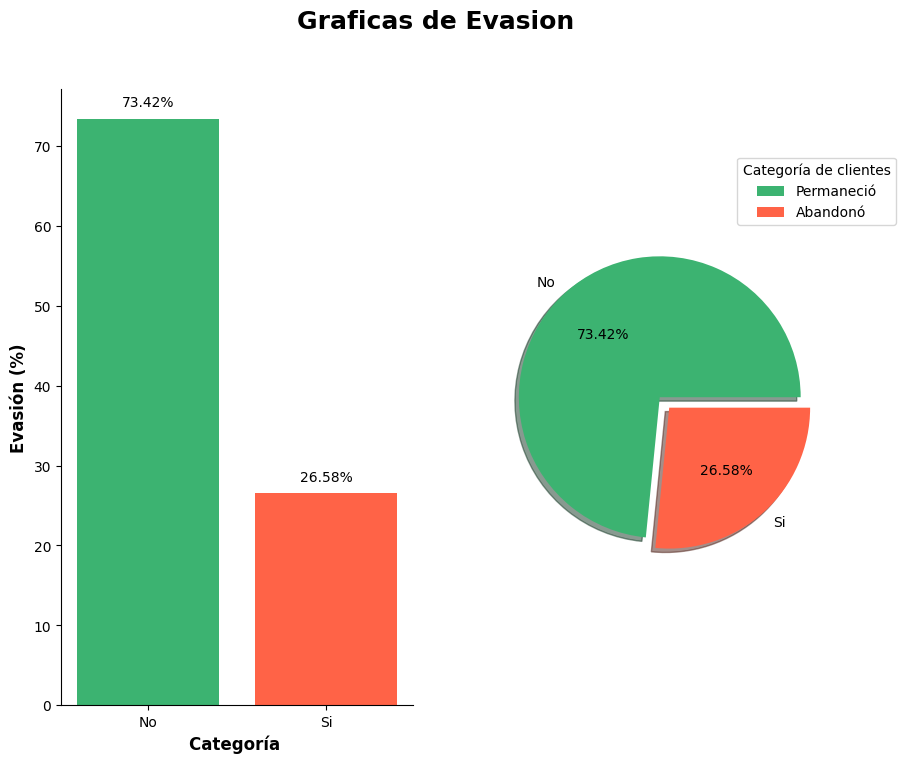

In [41]:
color = ['mediumseagreen', 'tomato']
leyendas = ["Permaneció", "Abandonó"]
desfase = (0, 0.1)

def graf_evasion():
    fig, axs =plt.subplots(1,2, figsize=(10,8))
    fig.suptitle("Graficas de Evasion", fontsize=18, fontweight="bold")

    #Gráfica de barras
    axs[0].bar(df_evasion.index, df_evasion.values, color=color)
    axs[0].set_ylabel("Evasión (%)", fontsize=12, fontweight="bold")
    axs[0].set_xlabel("Categoría ", fontsize=12, fontweight="bold")
    axs[0].spines['top'].set_visible(False)
    axs[0].spines['right'].set_visible(False)
    for i, j in enumerate(df_evasion.values):
        axs[0].text(i,j+2,str(j.round(2))+"%",ha="center",va="center")

    #Gráfica de pie
    axs[1].pie(df_evasion, labels=df_evasion.index, colors=color, autopct="%1.2f%%", explode=desfase, shadow=True)
    axs[1].legend(title="Categoría de clientes", loc="upper left", bbox_to_anchor=(0.7, 1.2), labels=leyendas)
    #fig.savefig("grafico_evasion_cliente.jpg", transparent=True)
    return plt

graf_evasion().show()

In [24]:
df_normalizado.head(1)

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,1,0,1,1,0,One year,1,Mailed check,65.6,593.3


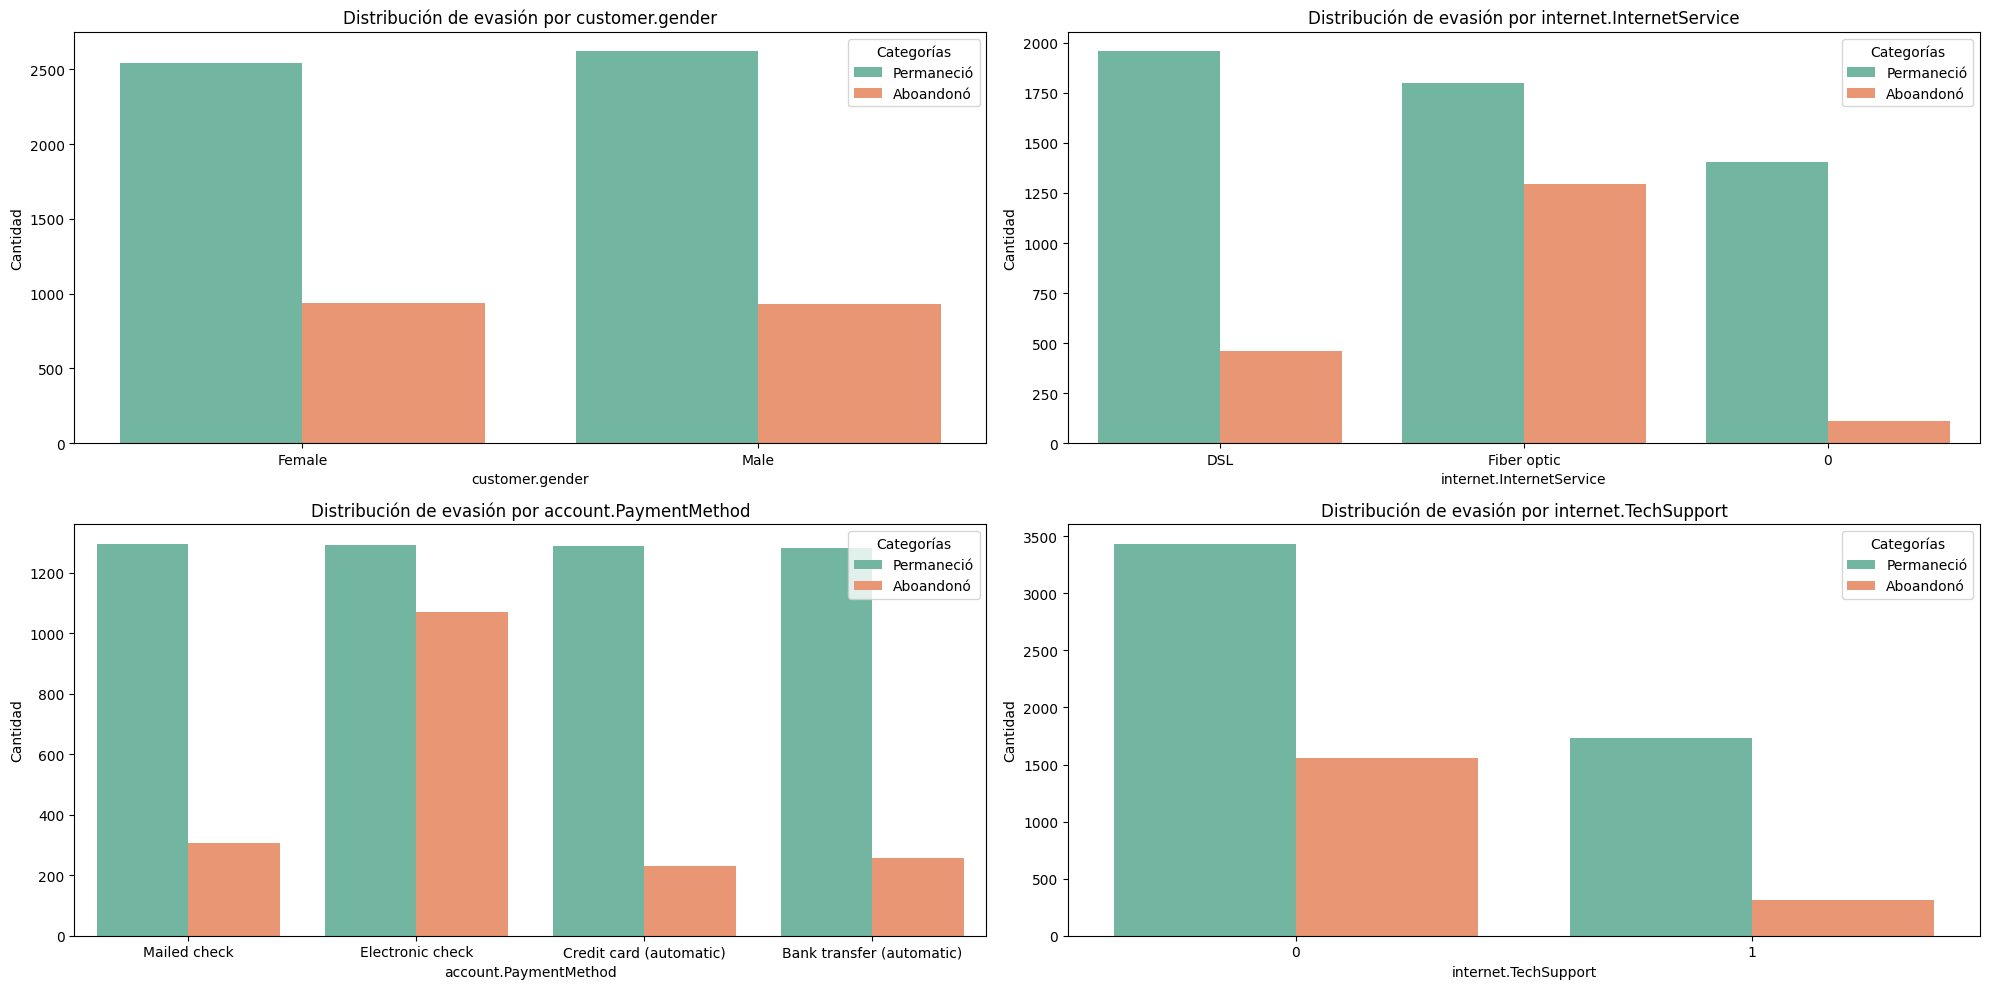

In [40]:
# Seleccionamos las 4 variables con mayor impacto en el negocio
columnas = [
    'customer.gender',            # Género
    'internet.InternetService',   # Tipo de contrato
    'account.PaymentMethod',      # Método de pago
    'internet.TechSupport'        # Soporte_Tecnico
]

fig, axes = plt.subplots(2,2, figsize=(20,10))
axes = axes.flatten()

for col, ax in zip(columnas, axes):
  sns.countplot(data=df_normalizado, hue="Churn", x=col, ax=ax, palette="Set2")
  ax.set_title(f'Distribución de evasión por {col}')
  ax.set_ylabel('Cantidad')
  ax.legend(title= 'Categorías', labels= ["Permaneció", "Aboandonó"])

plt.tight_layout()
plt.show()

/tmp/ipykernel_306/2801760168.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['Permanecen', 'Abandonaron'])
/tmp/ipykernel_306/2801760168.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['Permanecen', 'Abandonaron'])


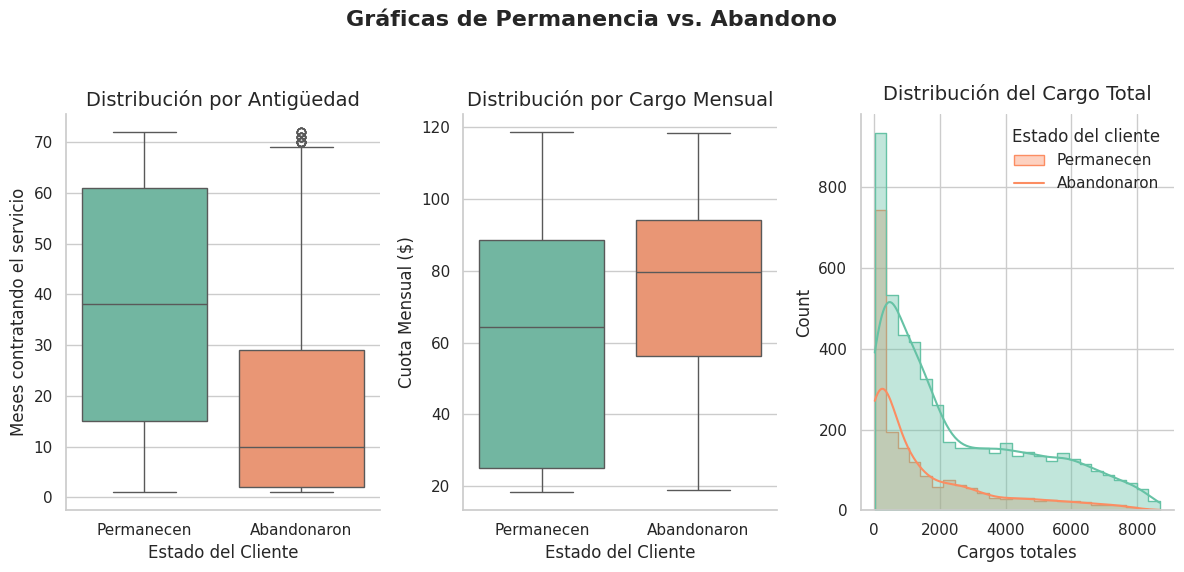

In [49]:
#Conteo de evasión por variables numéricas
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(1, 3, figsize=(12, 6))
fig.suptitle('Gráficas de Permanencia vs. Abandono', fontsize=16, fontweight='bold')

# Gráfico 1: Antigüedad
sns.boxplot(data=df_normalizado, x='Churn', y='customer.tenure',
            palette='Set2', ax=ax[0], hue='Churn', legend=False)
ax[0].set_title('Distribución por Antigüedad', fontsize=14)
ax[0].set_xlabel('Estado del Cliente', fontsize=12)
ax[0].set_ylabel('Meses contratando el servicio', fontsize=12)
ax[0].set_xticklabels(['Permanecen', 'Abandonaron'])

# Gráfico 2: Cargo Mensual
sns.boxplot(data=df_normalizado, x='Churn', y='account.Charges.Monthly',
            palette='Set2', ax=ax[1], hue='Churn', legend=False)
ax[1].set_title('Distribución por Cargo Mensual', fontsize=14)
ax[1].set_xlabel('Estado del Cliente', fontsize=12)
ax[1].set_ylabel('Cuota Mensual ($)', fontsize=12)
ax[1].set_xticklabels(['Permanecen', 'Abandonaron'])

# 3. Cargo Total
sns.histplot(data=df_normalizado, x='account.Charges.Total', hue='Churn',
             kde=True, element="step", palette='Set2', ax=ax[2], alpha=0.4)
ax[2].set_title('Distribución del Cargo Total', fontsize=14, pad=10)
ax[2].legend(title='Estado del cliente', labels=['Permanecen', 'Abandonaron'], frameon=False)
ax[2].set_xlabel('Cargos totales', fontsize=12)


sns.despine()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
#plt.savefig('figuras/distribucion_abandono_boxplot.png')
plt.show()



#📄Informe final

🔹 Introducción: Explica el objetivo del análisis y el problema de evasión de clientes (Churn).



🔹 Limpieza y Tratamiento de Datos: Describe los pasos realizados para importar, limpiar y procesar los datos.

🔹 Análisis Exploratorio de Datos: Presenta los análisis realizados, incluyendo gráficos y visualizaciones para identificar patrones.

🔹 Conclusiones e Insights: Resume los principales hallazgos y cómo estos datos pueden ayudar a reducir la evasión.

🔹 Recomendaciones: Ofrece sugerencias estratégicas basadas en tu análisis.